**Figure set: Repeated Comparison Baselines.** This notebook follows the existing FAST/USENIX style and renders four separate bar charts for mean, p50, p95, and p99 latency. Each bar is aggregated from 50 fresh-workspace repeats on the fixed comparison trajectory; red bars denote AgentTX full (ours), blue bars denote the no-trace/checkpoint group, and black/orange bars denote reference isolation baselines.


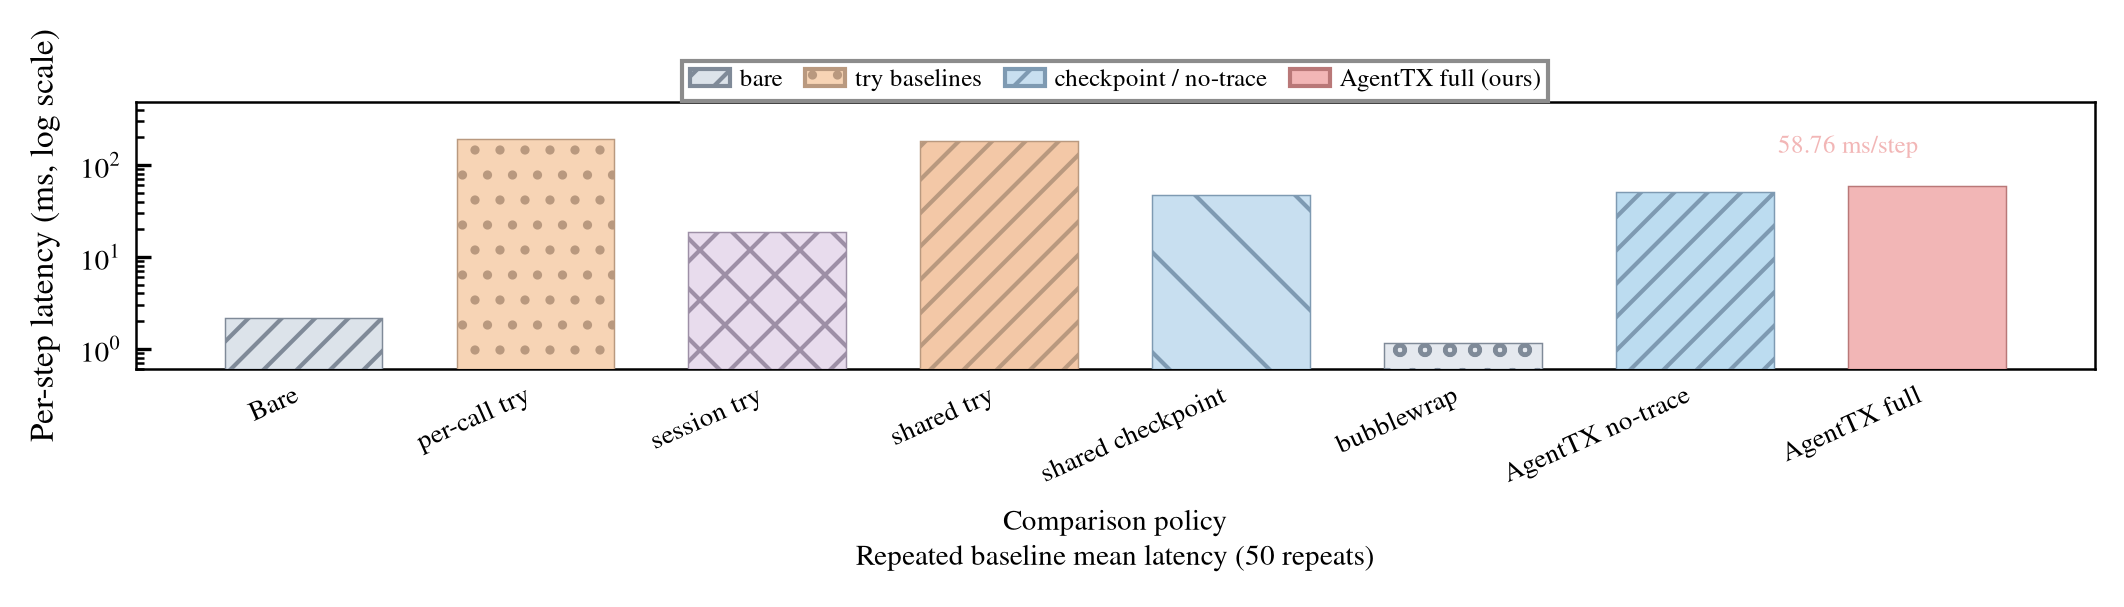

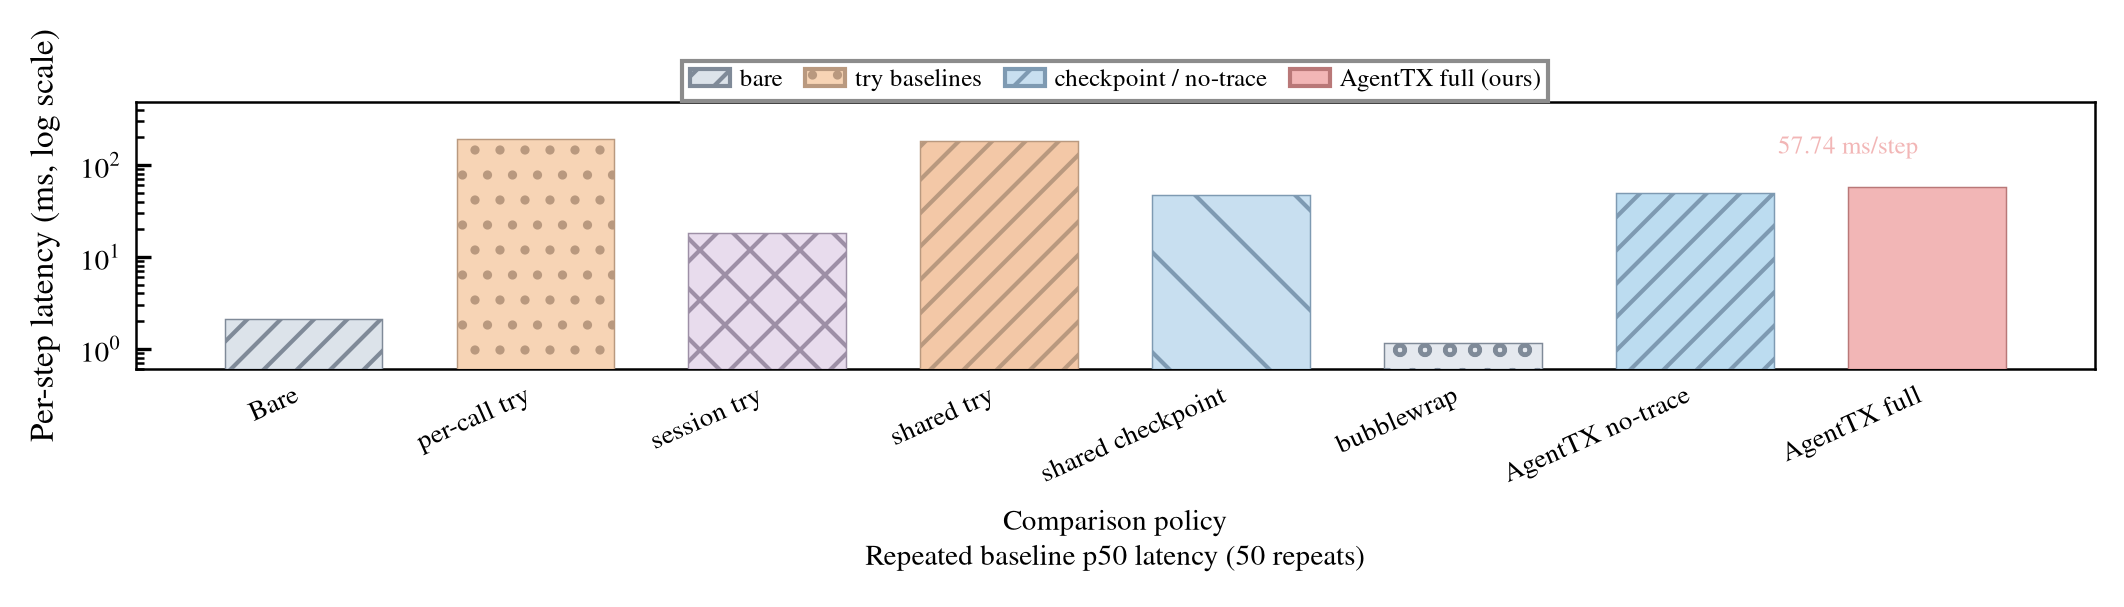

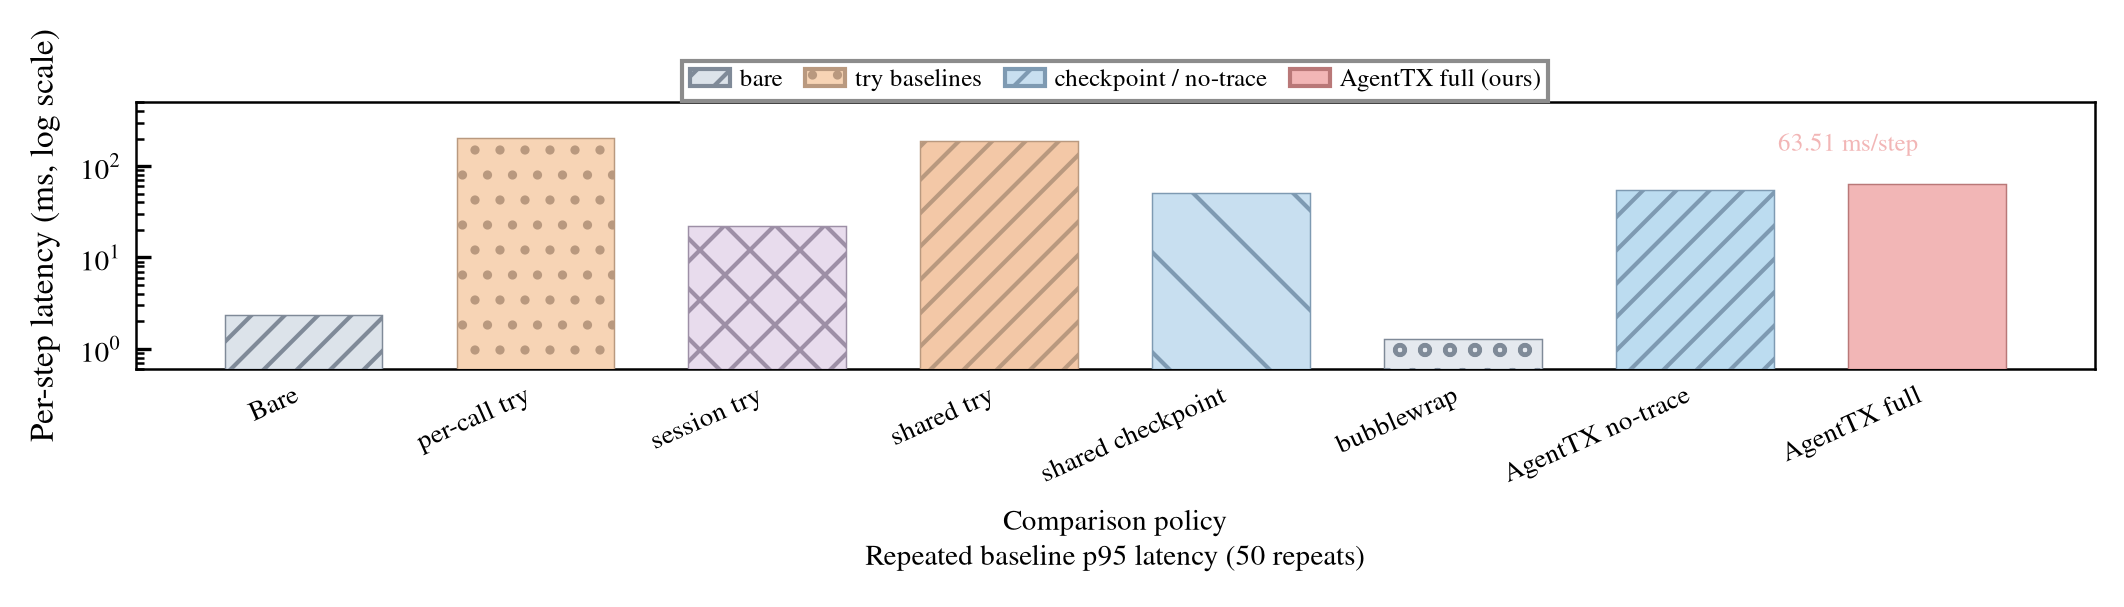

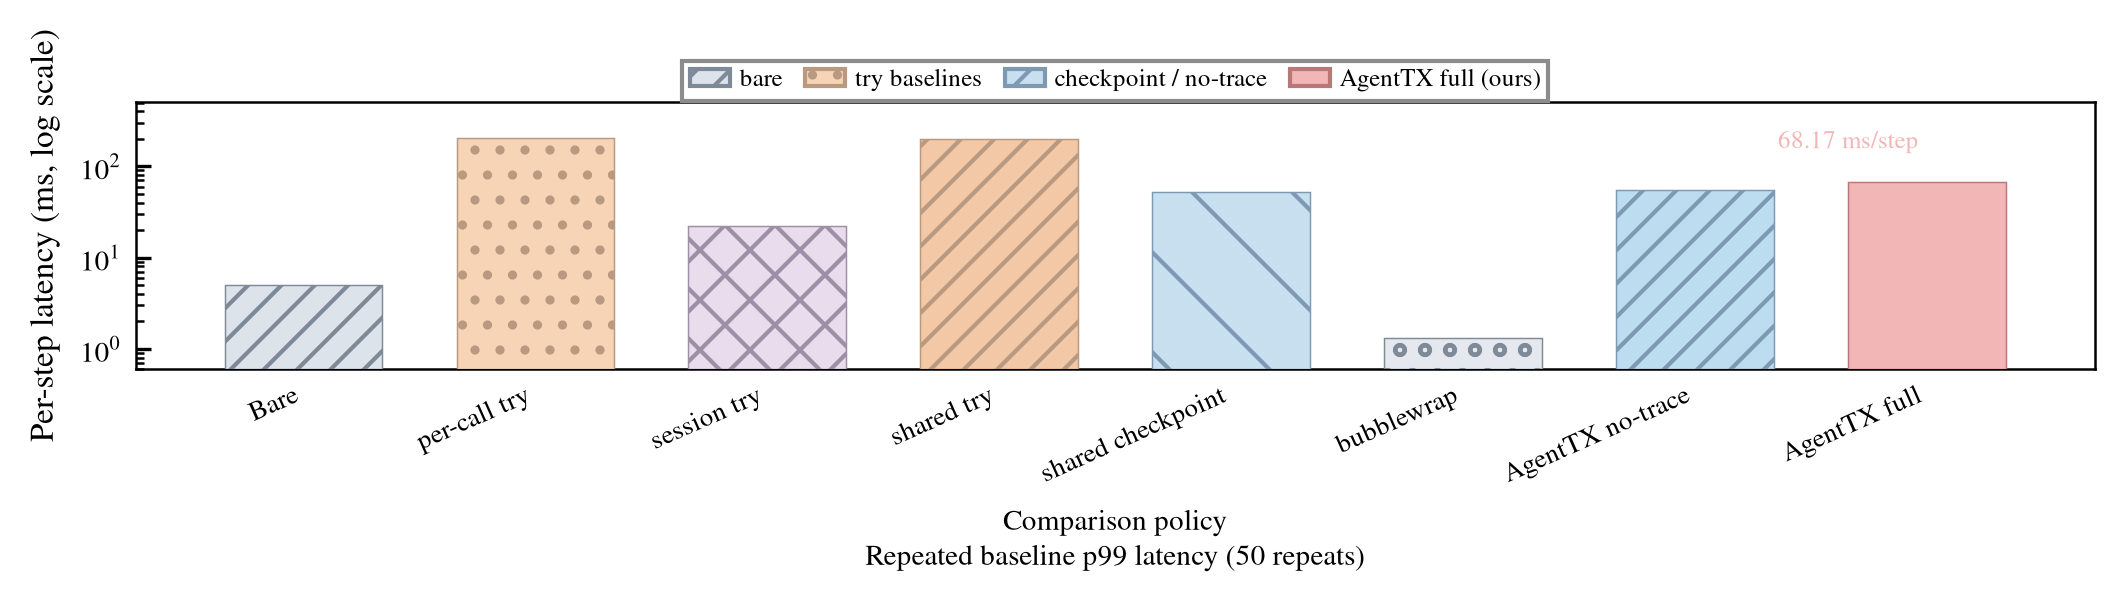

runtime rows: 8
AgentTX full p50/p95/p99: 57.738 63.511 68.169


In [1]:
# ipython -c "%run plot_comparison_repeats.ipynb"
# FAST/USENIX line-plot conventions: white panels, boxed top legend,
# red solid squares = AgentTX full (ours), blue triangles = no-trace.
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import pandas as pd
import numpy as np
from pathlib import Path

STANDARD_WIDTH = 17.8            # USENIX two-column text width, cm

def cm_to_inch(value):
    return value / 2.54

plt.rcParams.update(plt.rcParamsDefault)
matplotlib.rcParams['text.usetex'] = False
matplotlib.rcParams['font.family'] = 'Nimbus Roman'
matplotlib.rcParams['axes.grid'] = False
matplotlib.rcParams['axes.linewidth'] = 0.6
matplotlib.rcParams['xtick.direction'] = 'in'
matplotlib.rcParams['ytick.direction'] = 'in'
matplotlib.rcParams['legend.frameon'] = True
matplotlib.rcParams['legend.edgecolor'] = '0.55'
matplotlib.rcParams['legend.framealpha'] = 1.0
matplotlib.rcParams['legend.fancybox'] = False

OURS  = dict(color='#f2b6b6', edgecolor='#b97878', marker='s', linestyle='None', markersize=3.6)
BASE1 = dict(color='#f7d4b5', edgecolor='#b9997f', marker='x', linestyle='None', markersize=4.0, markeredgewidth=0.9)
BASE2 = dict(color='#c8dff0', edgecolor='#7e9ab2', marker='^', linestyle='None', markersize=3.8, markerfacecolor='none')
REF   = dict(color='#dce3ea', edgecolor='#7f8a98', marker='x', linestyle='None', markersize=3.8, markeredgewidth=0.8)

cwd = Path.cwd()
ROOT = cwd.parent if cwd.name == 'motivation' else cwd
RESULTS = ROOT / 'experiments' / 'results'
FIGDIR = ROOT / 'motivation'

df = pd.read_csv(RESULTS / 'comparison_repeats.csv')
runtime = df[df['suite'] == 'overhead'].set_index('mode')
modes = [
    'bare', 'per_call_try', 'session_try', 'shared_try',
    'shared_checkpoint', 'bubblewrap',
    'agenttx_without_read_tracing', 'agenttx_full',
]
labels = [
    'Bare', 'per-call try', 'session try', 'shared try',
    'shared checkpoint', 'bubblewrap', 'AgentTX no-trace', 'AgentTX full',
]
point_styles = {
    'bare': REF,
    'per_call_try': BASE1,
    'session_try': dict(color='#e8dced', edgecolor='#9d8fa6', marker='o', linestyle='None', markersize=3.5),
    'shared_try': dict(color='#f3c8a7', edgecolor='#b9997f', marker='D', linestyle='None', markersize=3.0),
    'shared_checkpoint': dict(color='#c8dff0', edgecolor='#7e9ab2', marker='v', linestyle='None', markersize=3.4, markerfacecolor='none'),
    'bubblewrap': dict(color='#e5e9ef', edgecolor='#7f8a98', marker='o', linestyle='None', markersize=3.3),
    'agenttx_without_read_tracing': BASE2,
    'agenttx_full': OURS,
}

legend_handles = [
    Patch(facecolor='#dce3ea', edgecolor='#7f8a98', hatch='///', label='bare'),
    Patch(facecolor='#f7d4b5', edgecolor='#b9997f', hatch='..', label='try baselines'),
    Patch(facecolor='#c8dff0', edgecolor='#7e9ab2', hatch='///', label='checkpoint / no-trace'),
    Patch(facecolor='#f2b6b6', edgecolor='#b97878', label='AgentTX full (ours)'),
]

bar_colors = ['#dce3ea', '#f7d4b5', '#e8dced', '#f3c8a7', '#c8dff0', '#e5e9ef', '#bcdcf0', '#f2b6b6']
bar_edges = ['#7f8a98', '#b9997f', '#9d8fa6', '#b9997f', '#7e9ab2', '#7f8a98', '#7e9ab2', '#b97878']
bar_hatches = ['///', '..', 'xx', '///', '\\', 'oo', '///', '']

def render(metric, title, filename):
    values = np.asarray([float(runtime.loc[mode, metric]) for mode in modes])
    x = np.arange(len(modes))
    baseline = 0.6
    fig, ax = plt.subplots(dpi=300, figsize=(cm_to_inch(STANDARD_WIDTH), cm_to_inch(5.6)))
    for index, value in enumerate(values):
        ax.bar(index, value - baseline, bottom=baseline, width=0.68,
               color=bar_colors[index], edgecolor=bar_edges[index], linewidth=0.35,
               hatch=bar_hatches[index], zorder=3)
    ax.set_yscale('log')
    ax.set_ylim(baseline, max(values) * 2.5)
    ax.set_xticks(x, labels=labels, rotation=24, ha='right', fontsize=6.5)
    ax.set_ylabel('Per-step latency (ms, log scale)', fontsize=8)
    ax.set_xlabel('Comparison policy\n' + title, fontsize=7)
    ax.tick_params(axis='y', labelsize=7)
    ax.grid(False)
    ax.legend(handles=legend_handles, loc='upper center', bbox_to_anchor=(0.5, 1.20),
              ncol=4, fontsize=6, columnspacing=0.9, handlelength=1.6,
              handletextpad=0.4, borderpad=0.3)
    ax.annotate(f"{values[-1]:.2f} ms/step", (x[-1], values[-1]),
                textcoords='offset points', xytext=(-2, 8), ha='right',
                fontsize=6, color=OURS['color'])
    plt.tight_layout(pad=0.45, rect=[0.0, 0.0, 1.0, 0.91])
    plt.savefig(FIGDIR / f'{filename}.pdf', bbox_inches='tight', pad_inches=0.02)
    plt.savefig(FIGDIR / f'{filename}.png', dpi=300, bbox_inches='tight', pad_inches=0.02)
    plt.show()

render('per_step_ms_mean', 'Repeated baseline mean latency (50 repeats)', 'FIG-Comparison-Mean')
render('per_step_ms_p50', 'Repeated baseline p50 latency (50 repeats)', 'FIG-Comparison-P50')
render('per_step_ms_p95', 'Repeated baseline p95 latency (50 repeats)', 'FIG-Comparison-P95')
render('per_step_ms_p99', 'Repeated baseline p99 latency (50 repeats)', 'FIG-Comparison-P99')

print('runtime rows:', len(runtime))
print('AgentTX full p50/p95/p99:',
      runtime.loc['agenttx_full', 'per_step_ms_p50'],
      runtime.loc['agenttx_full', 'per_step_ms_p95'],
      runtime.loc['agenttx_full', 'per_step_ms_p99'])

